# Хинчагов Руслан 
## Домашнее задание - 12

In [330]:
import random
import numpy as np
import matplotlib.pyplot as plt
import json

import math
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

RANDOM_STATE = 42 
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

import pandas as pd


In [331]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
set_seed(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

device = cpu


In [332]:
df = pd.read_csv('./data/S12-hw-dataset.csv')
print(df.head)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print("Размер датасета: ", df.shape)
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print("\nПропуски по колонкам:")
print(df.isnull().sum())

print(df['target'].describe())

<bound method NDFrame.head of                      date  target
0     2025-01-01 00:00:00   98.14
1     2025-01-01 01:00:00   98.07
2     2025-01-01 02:00:00  104.70
3     2025-01-01 03:00:00  112.81
4     2025-01-01 04:00:00  112.62
...                   ...     ...
4315  2025-06-29 19:00:00  153.05
4316  2025-06-29 20:00:00  134.23
4317  2025-06-29 21:00:00  137.68
4318  2025-06-29 22:00:00  126.53
4319  2025-06-29 23:00:00  120.89

[4320 rows x 2 columns]>
Размер датасета:  (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


In [333]:
if df['target'].isnull().sum() > 0:
    print("\nОбнаружены пропуски в target, юзаем forward-fill")
    df['target'] = df['target'].fillna(method='ffill')  
    print("Пропуски заполнены методом forward-fill (перенос предыдущего значения)")
else:
    print("\nПропуски в target отсутствуют")


Пропуски в target отсутствуют


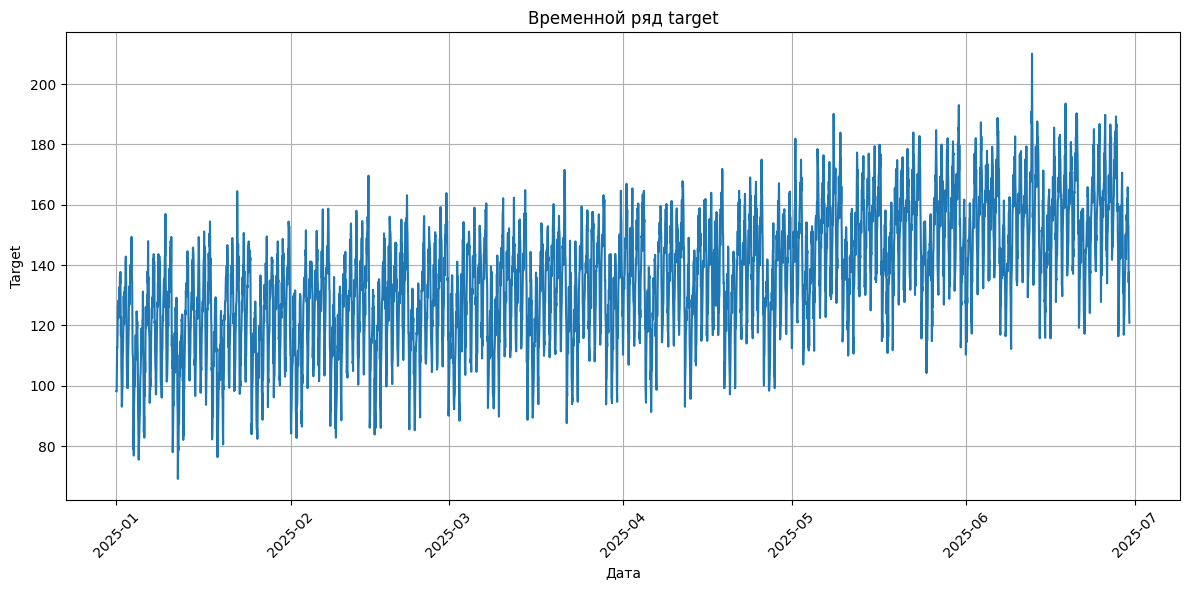

In [334]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['target'])
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Есть заметный скачки в времяном ряду, что может означать проведение акций

Также заметна сезонность где таргет постепенно растет к летнему периоду.

In [335]:
assert df['date'].is_monotonic_increasing, "Данные не отсортированы по времени!"

In [336]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70  
    val_frac: float = 0.15 
    
def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy() 
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


`Random Split` неккоректен для этой задачи, поскольку нам нужны последовательные временные ряды, test-ряд находится в другом положении от train, плюсом к этому модель будет подглядывать в будущее (Data Leakage)

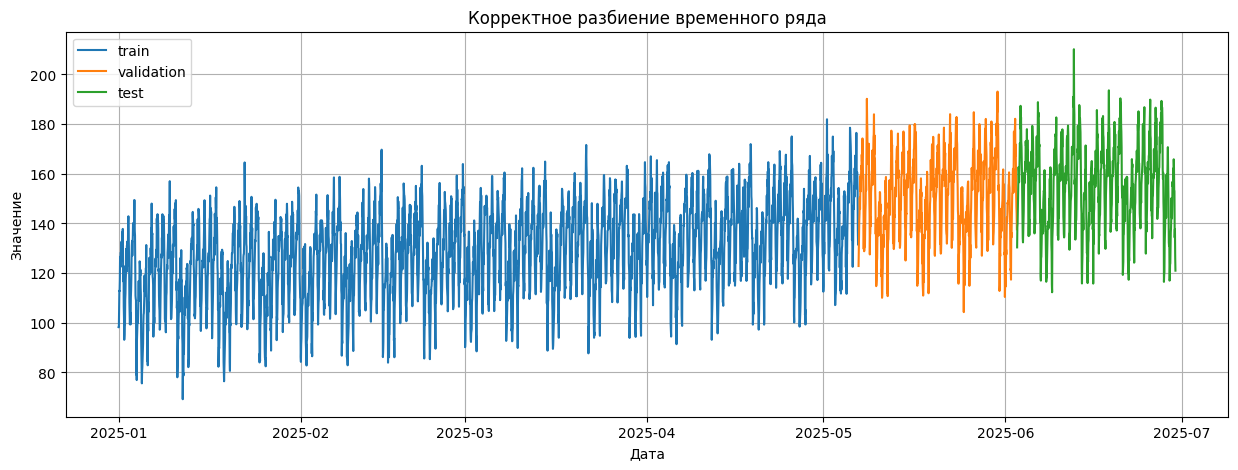

In [337]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректное разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

`Random Split` неккоректен для этой задачи, поскольку нам нужны последовательные временные ряды, test-ряд находится в другом положении от train, плюсом к этому модель будет подглядывать в будущее (Data Leakage)

In [338]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out['is_weekend'] = (out['dayofweek'] >= 5).astype(int)

    out['lag_1'] = out['target'].shift(1)
    out['lag_7'] = out['target'].shift(7)
    out['lag_14'] = out['target'].shift(14)
    
    out['rolling_mean_7'] = out['target'].shift(1).rolling(7, min_periods=1).mean()
    out['rolling_std_7'] = out['target'].shift(1).rolling(7, min_periods=1).std()
    
    return out

features_df = add_calendar_features(df)
features_df.head()

,date,target,dayofweek,month,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 00:00:00,98.14,2,1,0,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 01:00:00,98.07,2,1,0,98.14,NaN,NaN,98.140000,NaN
2,2025-01-01 02:00:00,104.70,2,1,0,98.07,NaN,NaN,98.105000,0.049497
3,2025-01-01 03:00:00,112.81,2,1,0,104.70,NaN,NaN,100.303333,3.807786
4,2025-01-01 04:00:00,112.62,2,1,0,112.81,NaN,NaN,103.430000,6.983576


In [339]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])       
        y.append(series_2d[i + window_size, 0])         
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_win, y_train_win = make_windows(train_scaled, window_size)
X_val_win, y_val_win = make_windows(val_scaled, window_size)
X_test_win, y_test_win = make_windows(test_scaled, window_size)

print("X_train:", X_train_win.shape, "y_train:", y_train_win.shape)
print("X_val  :", X_val_win.shape, "y_val  :", y_val_win.shape)
print("X_test :", X_test_win.shape, "y_test :", y_test_win.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -0.8963408


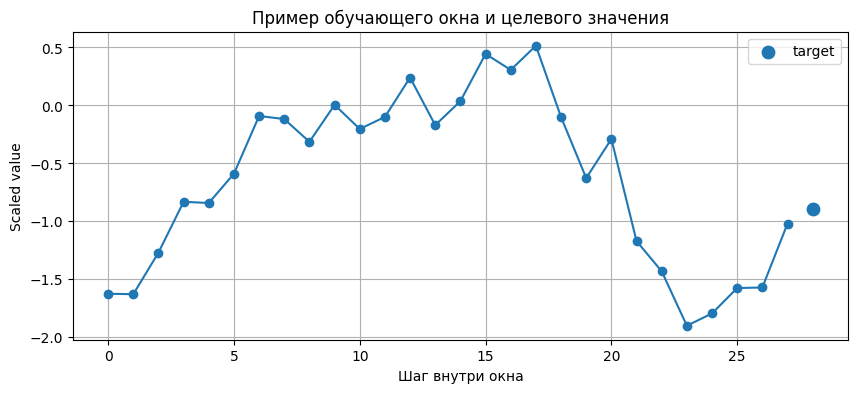

In [340]:
sample_idx = 0

print("Форма одного окна:", X_train_win[sample_idx].shape)
print("Первые 5 значений окна:", X_train_win[sample_idx][:5].ravel())
print("Цель:", y_train_win[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train_win[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train_win[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()


In [341]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  
        self.y = torch.tensor(y, dtype=torch.float32)  

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]
    
batch_size = 64

train_ds = TimeSeriesDataset(X_train_win, y_train_win)
val_ds = TimeSeriesDataset(X_val_win, y_val_win)
test_ds = TimeSeriesDataset(X_test_win, y_test_win)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)   
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)    
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  
print("Batch y:", yb.shape)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [342]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.rnn(x, (h0, c0))
        out = self.dropout(out[:, -1, :])  
        out = self.fc(out)
        return out

In [343]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred.squeeze(), y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

@torch.no_grad()
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss, total_mae = 0, 0
    predictions, targets = [], []
    
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        y_pred = model(X_batch)
        loss = criterion(y_pred.squeeze(), y_batch)
        
        total_loss += loss.item()
        mae = torch.mean(torch.abs(y_pred.squeeze() - y_batch))
        total_mae += mae.item()
        
        predictions.extend(y_pred.cpu().numpy())
        targets.extend(y_batch.cpu().numpy())
    
    return (total_loss / len(val_loader),
            total_mae / len(val_loader),
            predictions, targets)

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

In [344]:
def train_rnn_full(epochs=100, lr=0.001):
    model = RNNModel(input_size=1, hidden_size=64, num_layers=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    criterion = nn.MSELoss()
    
    history = {
        'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': [],
        'lr': [], 'best_val_loss': float('inf')
    }
    
    print("Начало обучения...")
    print("-" * 60)
    
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)

        val_loss, val_mae, val_preds, val_targets = validate_epoch(model, val_loader, criterion, device)
        val_rmse, _ = calculate_metrics(val_targets, val_preds)
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train: {train_loss:.4f} | "
                  f"Val: {val_loss:.4f} (RMSE: {val_rmse:.4f}, MAE: {val_mae:.4f}) | "
                  f"LR: {history['lr'][-1]:.2e}")
    
    print("-" * 60)
    print(f"Обучение завершено. Лучшая val_loss: {history['best_val_loss']:.4f}")
    return model, history

model, history = train_rnn_full(epochs=100, lr=0.001)

Начало обучения...
------------------------------------------------------------
Epoch   1/100 | Train: 0.7710 | Val: 0.6514 (RMSE: 0.8093, MAE: 0.6812) | LR: 1.00e-03
Epoch  10/100 | Train: 0.1542 | Val: 0.1777 (RMSE: 0.4234, MAE: 0.3328) | LR: 1.00e-03
Epoch  20/100 | Train: 0.1144 | Val: 0.1474 (RMSE: 0.3860, MAE: 0.3008) | LR: 1.00e-03
Epoch  30/100 | Train: 0.1085 | Val: 0.1413 (RMSE: 0.3778, MAE: 0.2925) | LR: 1.00e-03
Epoch  40/100 | Train: 0.1060 | Val: 0.1616 (RMSE: 0.4041, MAE: 0.3132) | LR: 5.00e-04
Epoch  50/100 | Train: 0.0995 | Val: 0.1499 (RMSE: 0.3890, MAE: 0.3006) | LR: 2.50e-04
Epoch  60/100 | Train: 0.0978 | Val: 0.1504 (RMSE: 0.3897, MAE: 0.2995) | LR: 2.50e-04
Epoch  70/100 | Train: 0.0971 | Val: 0.1494 (RMSE: 0.3883, MAE: 0.2980) | LR: 1.25e-04
Epoch  80/100 | Train: 0.0970 | Val: 0.1531 (RMSE: 0.3931, MAE: 0.3014) | LR: 6.25e-05
Epoch  90/100 | Train: 0.0974 | Val: 0.1501 (RMSE: 0.3892, MAE: 0.2971) | LR: 3.13e-05
Epoch 100/100 | Train: 0.0950 | Val: 0.1510 (RMSE:

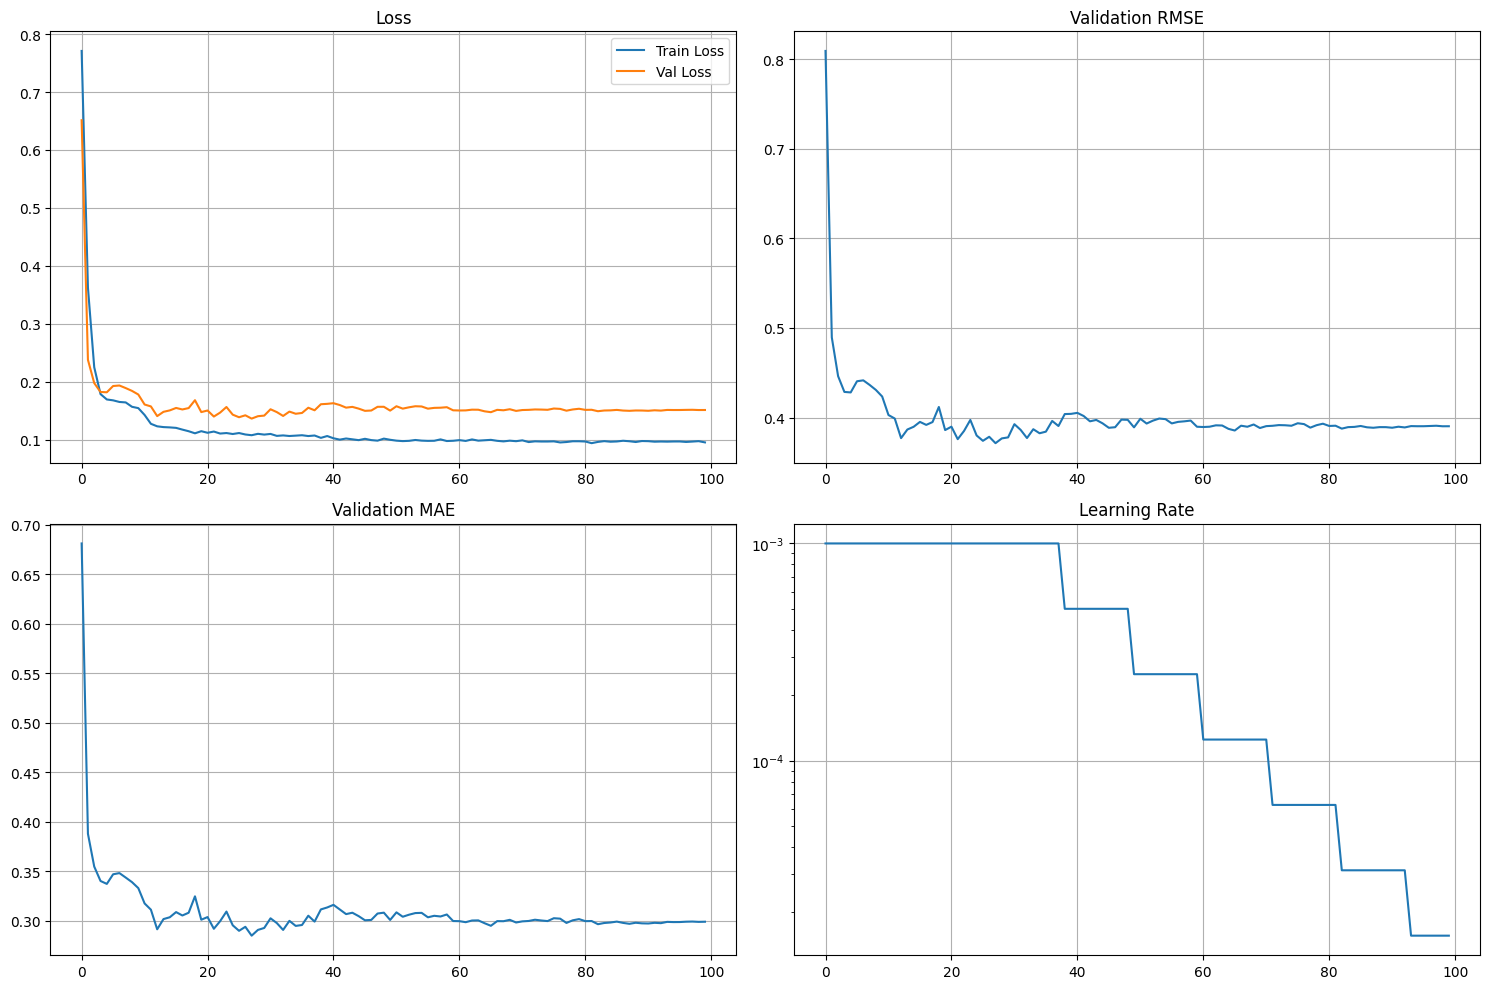

In [345]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


axes[0,0].plot(history['train_loss'], label='Train Loss')
axes[0,0].plot(history['val_loss'], label='Val Loss')
axes[0,0].set_title('Loss')
axes[0,0].legend()


axes[0,1].plot(history['val_rmse'], label='Val RMSE')
axes[0,1].set_title('Validation RMSE')


axes[1,0].plot(history['val_mae'], label='Val MAE')
axes[1,0].set_title('Validation MAE')

# Learning Rate
axes[1,1].plot(history['lr'])
axes[1,1].set_title('Learning Rate')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.savefig('./artifacts/figures/RNN_learn.png', dpi=300, bbox_inches='tight')
plt.show()

In [346]:
runs_df = pd.DataFrame(columns=[
    'experiment_id', 'task', 'dataset', 'seed', 'split_summary', 
    'window_size', 'horizon', 'model_summary', 'features_summary', 
    'scaler', 'optimizer', 'lr', 'epochs_trained', 
    'best_val_mae', 'best_val_rmse', 'best_val_mape',
    'test_mae', 'test_rmse', 'test_mape', 'notes'
])

def Predict(model, loader, device):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets

def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

def naive_baseline_from_windows(X: np.ndarray) -> np.ndarray:
    return X[:, -1, 0]


In [347]:
def log_experiment(experiment_id, model, history, val_metrics=None, test_metrics=None, 
                  epochs_trained=0, notes="", **params):
    global runs_df
        
    new_row = {
        'experiment_id': experiment_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': RANDOM_STATE,
        'split_summary': f"70/15/15 (train/val/test)",
        'window_size': window_size,
        'horizon': 1,  
        'model_summary': str(type(model).__name__),
        'features_summary': 'target + lags(1,7,14) + rolling(7) + calendar',
        'scaler': 'StandardScaler',
        'optimizer': params.get('optimizer', 'N/A'),
        'lr': params.get('lr', 0.0),
        'epochs_trained': epochs_trained,
        'best_val_mae': val_metrics.get('best_val_mae', np.nan),
        'best_val_rmse': val_metrics.get('best_val_rmse', np.nan),
        'best_val_mape': val_metrics.get('best_val_mape', np.nan),
        'test_mae': test_metrics.get('MAE', np.nan) if test_metrics else np.nan,
        'test_rmse': test_metrics.get('RMSE', np.nan) if test_metrics else np.nan,
        'test_mape': test_metrics.get('MAPE', np.nan) if test_metrics else np.nan,
        'notes': notes
    }
        
    runs_df = pd.concat([runs_df, pd.DataFrame([new_row])], ignore_index=True)

In [348]:
naive_val_pred = naive_baseline_from_windows(X_val_win)

val_metrics_raw = regression_metrics(y_val_win, naive_val_pred)

val_metrics_b1 = {
    'best_val_mae': val_metrics_raw['MAE'],
    'best_val_rmse': val_metrics_raw['RMSE'],
    'best_val_mape': val_metrics_raw['MAPE']
}

log_experiment(
    experiment_id="B1",
    model="native-last",
    val_metrics=val_metrics_b1,
    history=history,
    epochs_trained=0,
    optimizer='Adam',
    model_summary="NaiveLast",
    notes="Naive baseline (last value)"
)

print(runs_df)

  experiment_id         task             dataset seed  \
0            B1  forecasting  S12-hw-dataset.csv   42   

               split_summary window_size horizon model_summary  \
0  70/15/15 (train/val/test)          28       1           str   

                                features_summary          scaler optimizer  \
0  target + lags(1,7,14) + rolling(7) + calendar  StandardScaler      Adam   

    lr epochs_trained  best_val_mae  best_val_rmse  best_val_mape test_mae  \
0  0.0              0      0.349248       0.445803      94.564339      NaN   

  test_rmse test_mape                        notes  
0       NaN       NaN  Naive baseline (last value)  


/var/folders/r6/yd7rf7xx7yvfbgk45dzmbs1h0000gn/T/ipykernel_43571/1725096378.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs_df = pd.concat([runs_df, pd.DataFrame([new_row])], ignore_index=True)


In [349]:

train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat["date"]
y_train = train_feat["target"]

X_val = val_feat["date"]
y_val = val_feat["target"]

X_test = test_feat["date"]
y_test = test_feat["target"]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

val_pred_ma7 = val_feat["rolling_mean_7"].iloc[window_size:].values
test_pred_ma7 = test_feat["rolling_mean_7"].iloc[window_size:].values
metrics = regression_metrics(y_val.iloc[window_size:].values, val_pred_ma7)
val_metrics_prepared = {
    'best_val_mae': metrics.get('MAE', metrics.get('best_val_mae')),
    'best_val_rmse': metrics.get('RMSE', metrics.get('best_val_rmse')),
    'best_val_mape': metrics.get('MAPE', metrics.get('best_val_mape'))
}

log_experiment(
    experiment_id="B2",
    model="moving-average",
    val_metrics=val_metrics_prepared,
    history=history,
    optimizer='Adam',
    epochs_trained=0,
    notes="MovingAverage(7)"
)


Размерности:
X_train: (3024,) | y_train: (3024,)
X_val:   (648,) | y_val:   (648,)
X_test:  (648,) | y_test:  (648,)


In [350]:
ridge = Ridge(alpha=1.0)
X_train_2d = X_train_win.squeeze()
ridge.fit(X_train_2d, y_train_win)

val_pred_ridge = ridge.predict(X_val_win.squeeze())

metrics_b3_raw = regression_metrics(y_val_win, val_pred_ridge)

val_metrics_b3 = {
    'best_val_mae': metrics_b3_raw.get('MAE', metrics_b3_raw.get('best_val_mae')),
    'best_val_rmse': metrics_b3_raw.get('RMSE', metrics_b3_raw.get('best_val_rmse')),
    'best_val_mape': metrics_b3_raw.get('MAPE', metrics_b3_raw.get('best_val_mape'))
}

log_experiment(
    experiment_id="B3",
    model="ridge-lag-feuatuers",
    val_metrics=val_metrics_b3,
    test_targets=val_pred_ridge,
    history=history,
    optimizer='Adam',
    epochs_trained=0,
    notes="ridge-lag-featuers"
)

In [351]:
def fit_model(model, train_loader, val_loader, epochs=30, lr=5e-4, device=device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {
        "train_loss": [], 
        "val_loss": [], 
        "train_mae": [], 
        "val_mae": []
    }
    
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_mae = 0.0
        
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            preds = model(Xb)
            
            loss = criterion(preds.squeeze(), yb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_mae += torch.mean(torch.abs(preds.squeeze() - yb)).item()
            
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb)
                
                loss = criterion(preds.squeeze(), yb)
                val_loss += loss.item()
                val_mae += torch.mean(torch.abs(preds.squeeze() - yb)).item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_train_mae = train_mae / len(train_loader)
        avg_val_mae = val_mae / len(val_loader)
        
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_mae"].append(avg_train_mae)
        history["val_mae"].append(avg_val_mae)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict()

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Val MAE: {avg_val_mae:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
        
    return history

In [352]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred
    
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader,epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01/30 | Train Loss: 0.7461 | Val Loss: 0.5858 | Val MAE: 0.6558
Epoch 05/30 | Train Loss: 0.1658 | Val Loss: 0.1726 | Val MAE: 0.3324
Epoch 10/30 | Train Loss: 0.1562 | Val Loss: 0.1751 | Val MAE: 0.3330
Epoch 15/30 | Train Loss: 0.1281 | Val Loss: 0.1605 | Val MAE: 0.3166
Epoch 20/30 | Train Loss: 0.1080 | Val Loss: 0.1732 | Val MAE: 0.3220
Epoch 25/30 | Train Loss: 0.1040 | Val Loss: 0.1651 | Val MAE: 0.3149
Epoch 30/30 | Train Loss: 0.1018 | Val Loss: 0.1632 | Val MAE: 0.3135


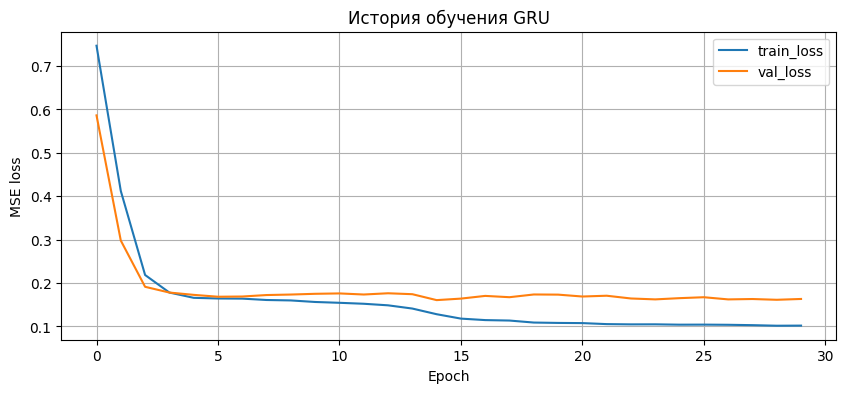

In [353]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()

In [354]:
gru_model.eval()
with torch.no_grad():
    y_val_pred_gru = gru_model(torch.tensor(X_val_win).to(device)).cpu().numpy()
val_m_r1 = regression_metrics(y_val_win, y_val_pred_gru)

with torch.no_grad():
    y_test_pred_gru_scaled = gru_model(torch.tensor(X_test_win).to(device)).cpu().numpy()


y_test_true = inverse_scale(y_test_win, scaler)
y_test_pred = inverse_scale(y_test_pred_gru_scaled, scaler)
test_m_r1 = {
    "MAE": mean_absolute_error(y_test_true, y_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
    "MAPE": np.mean(np.abs((y_test_true - y_test_pred) / y_test_true)) * 100
}



log_experiment(
    experiment_id="R1",
    model="gru-forecast",
    val_metrics=val_m_r1,
    test_metrics=test_m_r1,
    history=gru_history,
    lr=0.0005,
    optimizer='Adam',
    epochs_trained=30,
    notes="GRU на оконном представлении ряда."
)

/var/folders/r6/yd7rf7xx7yvfbgk45dzmbs1h0000gn/T/ipykernel_43571/1725096378.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs_df = pd.concat([runs_df, pd.DataFrame([new_row])], ignore_index=True)


In [355]:
runs_df.to_csv('./artifacts/runs.csv', index=False)
torch.save(gru_model.state_dict(), './artifacts/best_gru.pt')

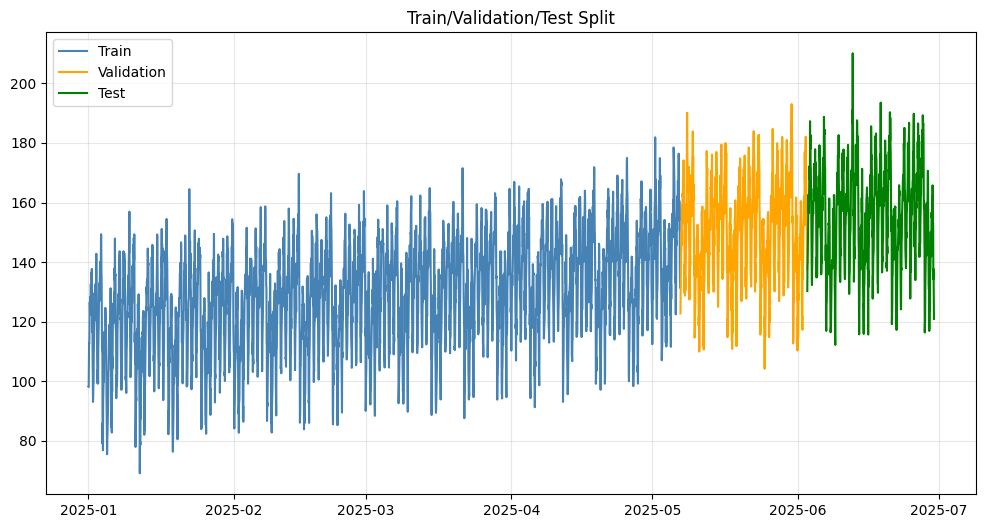

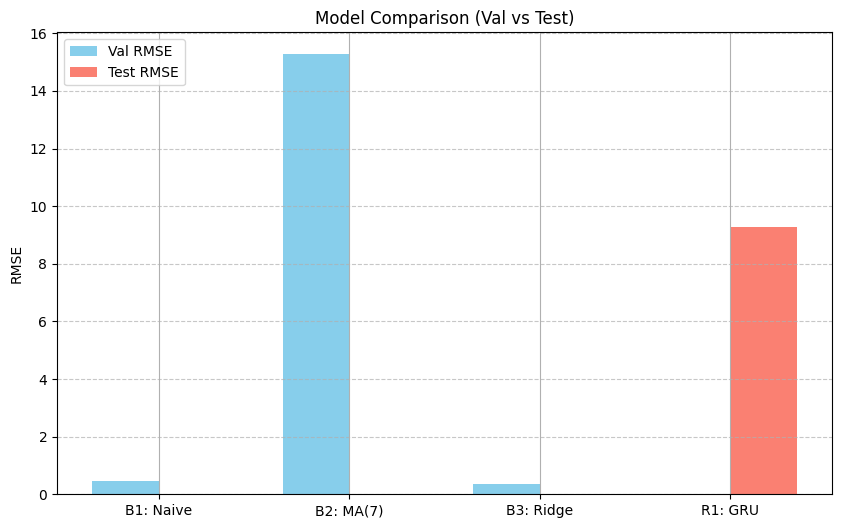

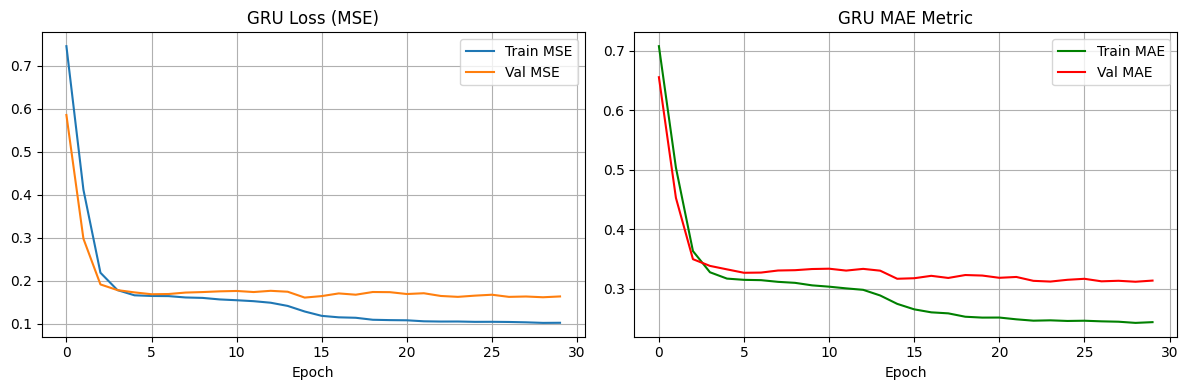

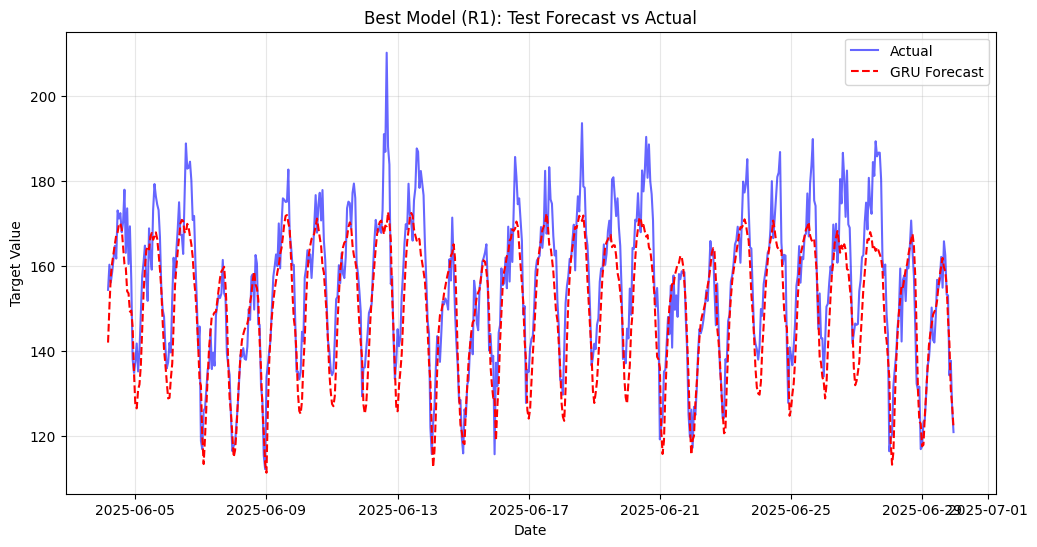

In [356]:
gru_config = {
   "experiment_id": "R1",
    "model": "gru-forecast",
    "architecture": {
        "window_size": window_size,
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.2
    },
    "training": {
        "seed": RANDOM_STATE,
        "batch_size": 32,
        "learning_rate": 5e-4,
        "epochs": 30,
        "optimizer": "Adam",
        "loss": "MSELoss"
    },
    "scaler": "StandardScaler"
}

with open('./artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(gru_config, f, indent=2, ensure_ascii=False)
    
    
plt.figure(figsize=(12, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='steelblue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange') 
plt.plot(test_df['date'], test_df['target'], label='Test', color='green')
plt.title('Train/Validation/Test Split')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./artifacts/figures/series_split.png', dpi=300)
plt.show()

baseline_metrics = runs_df[runs_df['experiment_id'].isin(['B1', 'B2', 'B3', 'R1'])].copy()
mapping = {
    'B1': 'B1: Naive',
    'B2': 'B2: MA(7)',
    'B3': 'B3: Ridge',
    'R1': 'R1: GRU'
}
baseline_metrics['ModelName'] = baseline_metrics['experiment_id'].map(mapping)

plt.figure(figsize=(10, 6))
x = np.arange(len(baseline_metrics))
width = 0.35
plt.bar(x - width/2, baseline_metrics['best_val_rmse'], width, label='Val RMSE', color='skyblue')
plt.bar(x + width/2, baseline_metrics['test_rmse'].fillna(0), width, label='Test RMSE', color='salmon')

plt.xticks(x, baseline_metrics['ModelName'])
plt.ylabel('RMSE')
plt.title('Model Comparison (Val vs Test)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('./artifacts/figures/baselines_compare.png', dpi=300)
plt.show()


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(gru_history['train_loss'], label='Train MSE')
plt.plot(gru_history['val_loss'], label='Val MSE') 
plt.title('GRU Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gru_history['train_mae'], label='Train MAE', color='green')
plt.plot(gru_history['val_mae'], label='Val MAE', color='red')
plt.title('GRU MAE Metric')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('./artifacts/figures/gru_learning_curves.png', dpi=300)
plt.show()

test_dates = test_df['date'].values[window_size:] 
actual_values = test_df['target'].values[window_size:]

gru_model.eval()
with torch.no_grad():
    y_test_pred_scaled = gru_model(torch.tensor(X_test_win).to(device)).cpu().numpy()
    y_test_pred = inverse_scale(y_test_pred_scaled, scaler)

plt.figure(figsize=(12, 6))
plt.plot(test_dates, actual_values, label='Actual', color='blue', alpha=0.6)
plt.plot(test_dates, y_test_pred, label='GRU Forecast', color='red', linestyle='--')
plt.title('Best Model (R1): Test Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./artifacts/figures/best_forecast_test.png', dpi=300)
plt.show()

In [357]:
valid_test_runs = runs_df[runs_df['test_rmse'].notna()]

if len(valid_test_runs) > 0:
    best_idx = valid_test_runs['test_rmse'].idxmin()
    best_row = runs_df.loc[best_idx]
    
    print(f"Лучшая модель: {best_row['experiment_id']}")
    print(f"Test RMSE: {best_row['test_rmse']:.4f}")
    print(f"Test MAE:  {best_row['test_mae']:.4f}")
    print(f"Test MAPE: {best_row['test_mape']:.2f}%")
else:
    print("Ошибка: В runs_df не найдены тестовые метрики! Убедитесь, что вы залогировали R1 с параметром test_metrics.")
    print(runs_df[['experiment_id', 'best_val_rmse', 'test_rmse']])

best_row = runs_df.loc[runs_df['test_rmse'].idxmin()]
final_results = {
    'best_model': str(best_row['experiment_id']),
    'test_rmse': float(best_row['test_rmse']),
    'test_mae': float(best_row['test_mae']),
    'test_mape': float(best_row['test_mape']),
    'timestamp': pd.Timestamp.now().isoformat()
}

with open('./artifacts/final_test_evaluation.json', 'w') as f:
    json.dump(final_results, f, indent=2)

Лучшая модель: R1
Test RMSE: 9.2747
Test MAE:  7.3533
Test MAPE: 4.68%
